In [26]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [27]:
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
from flax import linen as nn
import optax
import copy

from typing import Callable

from functools import partial

import tensorflow as tf
import tensorrt

from pyDOE import lhs
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint

import numpy as np

from jax.scipy.optimize import minimize
from scipy.optimize import fsolve

import warnings
import math

from collections import deque

In [28]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [29]:
print(jax.default_backend())

gpu


In [30]:
def flatten_pytree(params):
  values, tree_info = jax.tree_util.tree_flatten(params)

  no_leaves = len(values)
  shapes = []
  flattened = []

  for i in range(no_leaves):
    flattened.append(values[i].flatten())
    shapes.append(values[i].shape)

  return tree_info, shapes, jnp.concatenate(flattened)


def reconstruct_pytree(tree_info, shapes, flattened):

  values = []
  k = 0
  for i in range(len(shapes)):
    values.append(np.reshape(flattened[k:k+np.prod(shapes[i])], shapes[i]))
    k += np.prod(shapes[i])

  py_tree = jax.tree_util.tree_unflatten(tree_info, values)
  return py_tree

In [31]:
t0, tfinal = 0.0, 1.0

In [32]:
def TodaLatt(w, t):
    
    p1, p2, q1, q2 = w

    p1_t = -jnp.exp(q1 - q2) + jnp.exp(q2 - q1)
    q1_t = p1

    p2_t = jnp.exp(q1 - q2) - jnp.exp(q2 - q1)
    q2_t = p2

    dwdt = [p1_t, p2_t, q1_t, q2_t]

    return dwdt

In [33]:
@jax.jit
def calc_H(p1, p2, q1, q2) :

    H = (p1**2)/2 + (p2**2)/2 + jnp.exp(q1 - q2) + jnp.exp(q2 - q1)

    return H

In [123]:
Hmax = 1.0 + np.exp(2) + np.exp(-2)
Hmin = 2.0

print(Hmin, Hmax)

2.0 8.524391382167263


In [35]:
@jax.jit
def calc_ab(p1, p2, q1, q2) :

    a1 = -0.5*p1
    a2 = -0.5*p2

    b1 = 0.5*jnp.exp(0.5*(q1-q2))
    b2 = 0.5*jnp.exp(0.5*(q2-q1))

    return a1, a2, b1, b2

In [69]:
@jax.jit
def calc_evals(a1, a2, b1, b2) :
    
    eigen1 = ((a1 + a2) - jnp.sqrt((a1 - a2)**2 + 4*b1**2))/2
    eigen2 = ((a1 + a2) + jnp.sqrt((a1 - a2)**2 + 4*b1**2))/2

    evals = jnp.array([eigen1, eigen2])

    return evals

In [70]:
calc_evals(1.0, 2.0, 3.0, 4.0)

Array([-1.54138127,  4.54138127], dtype=float64)

In [38]:
@jax.jit
def calc_evals_pq(p1, p2, q1, q2) :

    a1, a2, b1, b2 = calc_ab(p1, p2, q1, q2)
    
    a1 = jnp.reshape(a1, (-1,))
    a2 = jnp.reshape(a2, (-1,))
    b1 = jnp.reshape(b1, (-1,))
    b2 = jnp.reshape(b2, (-1,))
    
    evals = jax.vmap(calc_evals, (0, 0, 0, 0), 0)(a1, a2, b1, b2)
    evals = jnp.reshape(evals, (-1,))
    
    return evals 

In [132]:
def define_collocation_points(t_bdry, N=100):

    ode_points = t_bdry[0] + (t_bdry[1] - t_bdry[0])*lhs(1, N)

    p1s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    p2s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    q1s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    q2s = np.random.uniform(-1.0, 1.0, size=(N, 1))
    Hs = calc_H(p1s, p2s, q1s, q2s)

    evals = jax.vmap(calc_evals_pq, (0), 0)(p1s, p2s, q1s, q2s)
    Hs_test = 2*(evals[:, :1]**2 + evals[:, 1:]**2)

    ode_points = np.column_stack((ode_points, Hs, evals))
    zsensors = np.column_stack((p1s, p2s, q1s, q2s))
    
    return (ode_points, zsensors)

In [133]:
(de_points, zsensors) = define_collocation_points([t0, tfinal], 100000)
print(de_points.shape, zsensors.shape)

(100000, 4) (100000, 4)


In [134]:
Hmax_act = np.max(de_points[:, 1])
Hmin_act = np.min(de_points[:, 1])

print(Hmax, Hmax_act)
print(Hmin, Hmin_act)

8.524391382167263 8.00879832386214
2.0 2.000309639273285


In [43]:
class Normalize(nn.Module):
  xmin: float
  xmax: float

  @nn.compact
  def __call__(self, x):
    return 2.0*(x-self.xmin)/(self.xmax - self.xmin) - 1.0

In [44]:
class HardConstraint(nn.Module):
  t0: float
  tfinal: float
  u0: float

  @nn.compact
  def __call__(self, inputs):
    t, nn = inputs
    return self.u0 + (t-self.t0)/(self.tfinal-self.t0)*nn

In [45]:
class CombineBranches(nn.Module):
  @nn.compact
  def __call__(self, inp1, inp2):
    mult = jnp.sum(inp1*inp2, axis=1)
    out = jnp.reshape(mult, (-1,1))
    return out

In [46]:
class MLP(nn.Module):

  layers: int
  units: int

  @nn.compact
  def __call__(self, inp):
    b = inp
    for i in range(self.layers-1):
      b = nn.Dense(self.units)(b)
      b = nn.tanh(b)
    out = nn.Dense(4*self.units)(b)
    return out

In [47]:
class DeepONet(nn.Module):

  t0: float
  tfinal: float
  Hmin: float
  Hmax: float
  layers: int 
  units: int

  @nn.compact
  def __call__(self, tHE, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tHE.ndim == 1:
      tHE = jnp.reshape(tHE, (1,-1)) 

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    H_0_norm = Normalize(self.Hmin, self.Hmax)(H_0)
   
    p1_0 = u[:, :1]
    p2_0 = u[:, 1:2]
    q1_0 = u[:, 2:3]
    q2_0 = u[:, 3:]

    u = jnp.column_stack((p1_0, p2_0, q1_0, q2_0))

    # b = t_0_norm
    b = jnp.column_stack((t_0_norm, H_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_p1 = trunk_net[:, :self.units]
    trunk_p2 = trunk_net[:, self.units:2*self.units]
    trunk_q1 = trunk_net[:, 2*self.units:3*self.units]
    trunk_q2 = trunk_net[:, 3*self.units:]
   
    branch_p1 = branch_net[:, :self.units]
    branch_p2 = branch_net[:, self.units:2*self.units]
    branch_q1 = branch_net[:, 2*self.units:3*self.units]
    branch_q2 = branch_net[:, 3*self.units:]
  
    p1 = CombineBranches()(trunk_p1, branch_p1)
    p2 = CombineBranches()(trunk_p2, branch_p2)
    q1 = CombineBranches()(trunk_q1, branch_q1)
    q2 = CombineBranches()(trunk_q2, branch_q2)
      
    p1 = HardConstraint(self.t0, self.tfinal, p1_0)([t_0, p1])
    p2 = HardConstraint(self.t0, self.tfinal, p2_0)([t_0, p2])
    q1 = HardConstraint(self.t0, self.tfinal, q1_0)([t_0, q1])
    q2 = HardConstraint(self.t0, self.tfinal, q2_0)([t_0, q2])
      
    p1 = jnp.reshape(p1, (-1,))
    p2 = jnp.reshape(p2, (-1,))
    q1 = jnp.reshape(q1, (-1,))
    q2 = jnp.reshape(q2, (-1,))

    return p1, p2, q1, q2

In [48]:
@partial(jax.jit, static_argnums=(2,))
def var_model(t, z, component, params):
  return deeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def var(t, z, component, params):
  return jax.vmap(var_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def var_t(t, z, component, params):
  return jax.vmap(jax.grad(var_model, 0), [0, 0, None, None])(t, z, component, params)

@jax.jit
def loss(params, tHE, z):
    
    p1_t_loss_w = 1.0
    p2_t_loss_w = 1.0
    q1_t_loss_w = 1.0
    q2_t_loss_w = 1.0   
    
    diff_loss_w = 1.0
    H_loss_w = 1.0

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:]
    
    p1_0 = z[:, :1]
    p2_0 = z[:, 1:2]
    q1_0 = z[:, 2:3]
    q2_0 = z[:, 3:]
    
    p1 = var(tHE, z, 0, params)
    p2 = var(tHE, z, 1, params)
    q1 = var(tHE, z, 2, params)
    q2 = var(tHE, z, 3, params)
    
    H = calc_H(p1, p2, q1, q2)
    H = jnp.reshape(H, (-1, 1))
    
    dp1_tHE = var_t(tHE, z, 0, params)
    dp2_tHE = var_t(tHE, z, 1, params)
    dq1_tHE = var_t(tHE, z, 2, params)
    dq2_tHE = var_t(tHE, z, 3, params)
        
    p1_t = dp1_tHE[:, 0]
    p2_t = dp2_tHE[:, 0]  
    q1_t = dq1_tHE[:, 0]
    q2_t = dq2_tHE[:, 0]
    
    H_loss = H - H_0
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)

    p1_t_loss = p1_t - (-jnp.exp(q1 - q2) + jnp.exp(q2 - q1))
    p1_t_loss = jnp.square(p1_t_loss)
    p1_t_loss = jnp.mean(p1_t_loss)

    q1_t_loss = q1_t - p1
    q1_t_loss = jnp.square(q1_t_loss)
    q1_t_loss = jnp.mean(q1_t_loss)
    
    p2_t_loss = p2_t - (jnp.exp(q1 - q2) - jnp.exp(q2 - q1))
    p2_t_loss = jnp.square(p2_t_loss)
    p2_t_loss = jnp.mean(p2_t_loss)
    
    q2_t_loss = q2_t - p2
    q2_t_loss = jnp.square(q2_t_loss)
    q2_t_loss = jnp.mean(q2_t_loss)
        
    diff_loss = p1_t_loss + p2_t_loss + q1_t_loss + q2_t_loss
    
    total_loss = diff_loss + H_loss

    return total_loss

@jax.jit
def train_step(params, pdes, z):
    t = pdes[:, :]
    
    return jax.value_and_grad(loss, has_aux = False)(params, t, z)

@partial(jax.jit, static_argnums=(3,))
def optimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [49]:
def train_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-3
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = train_step(params, des_batch.numpy(), z_batch.numpy())
            params, opt_state = optimize(grads, opt_state, params, optimizer.update)

            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [50]:
deeponet = DeepONet(t0, tfinal, Hmin, Hmax, layers=4, units=40)

t_init = jnp.full((10, 4), 1.0)
u_init = jnp.full((10, 4), 1.0)

params = deeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [51]:
param_count = sum(x.size for x in jax.tree.leaves(params))
print(param_count)

26560


In [52]:
epochs = 5000
params, loss = train_network(params, de_points, zsensors, epochs)


batch size: 100


I0000 00:00:1740375944.433135  173586 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 438 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Loss in epoch 0: 1.8685052502045858
Loss in epoch 100: 0.0029756635074160787
Loss in epoch 200: 0.0013734964711488002
Loss in epoch 300: 0.0008885604074955521
Loss in epoch 400: 0.003934435597749936
Loss in epoch 500: 0.000454862965862726
Loss in epoch 600: 0.0004165782533047086
Loss in epoch 700: 0.00132013828287803
Loss in epoch 800: 0.0002641874069753309
Loss in epoch 900: 0.0024866353732694744
Loss in epoch 1000: 0.0002724396858361932
Loss in epoch 1100: 0.00023593245365994672
Loss in epoch 1200: 0.00012611038334782085
Loss in epoch 1300: 0.00013439235131580706
Loss in epoch 1400: 0.00029946963947979986
Loss in epoch 1500: 0.00010963776394103412
Loss in epoch 1600: 0.000281883630105622
Loss in epoch 1700: 9.853368691701252e-05
Loss in epoch 1800: 5.8235456385136335e-05
Loss in epoch 1900: 0.00018948277727146113
Loss in epoch 2000: 0.000597724048616749
Loss in epoch 2100: 0.0004503761004046331
Loss in epoch 2200: 0.002133095446924453
Loss in epoch 2300: 0.00013865809607347995
Loss i

In [53]:
# params_5000ep = copy.deepcopy(params)

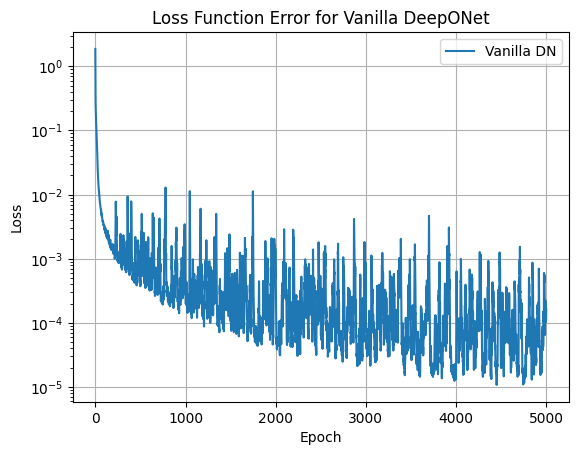

In [54]:
start = 0
stop = 5000

plt.semilogy(loss[start:stop])
plt.legend(['Vanilla DN'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title("Loss Function Error for Vanilla DeepONet")
plt.grid()
#plt.savefig('Toda3_vanilla_loss_5000ep.png')

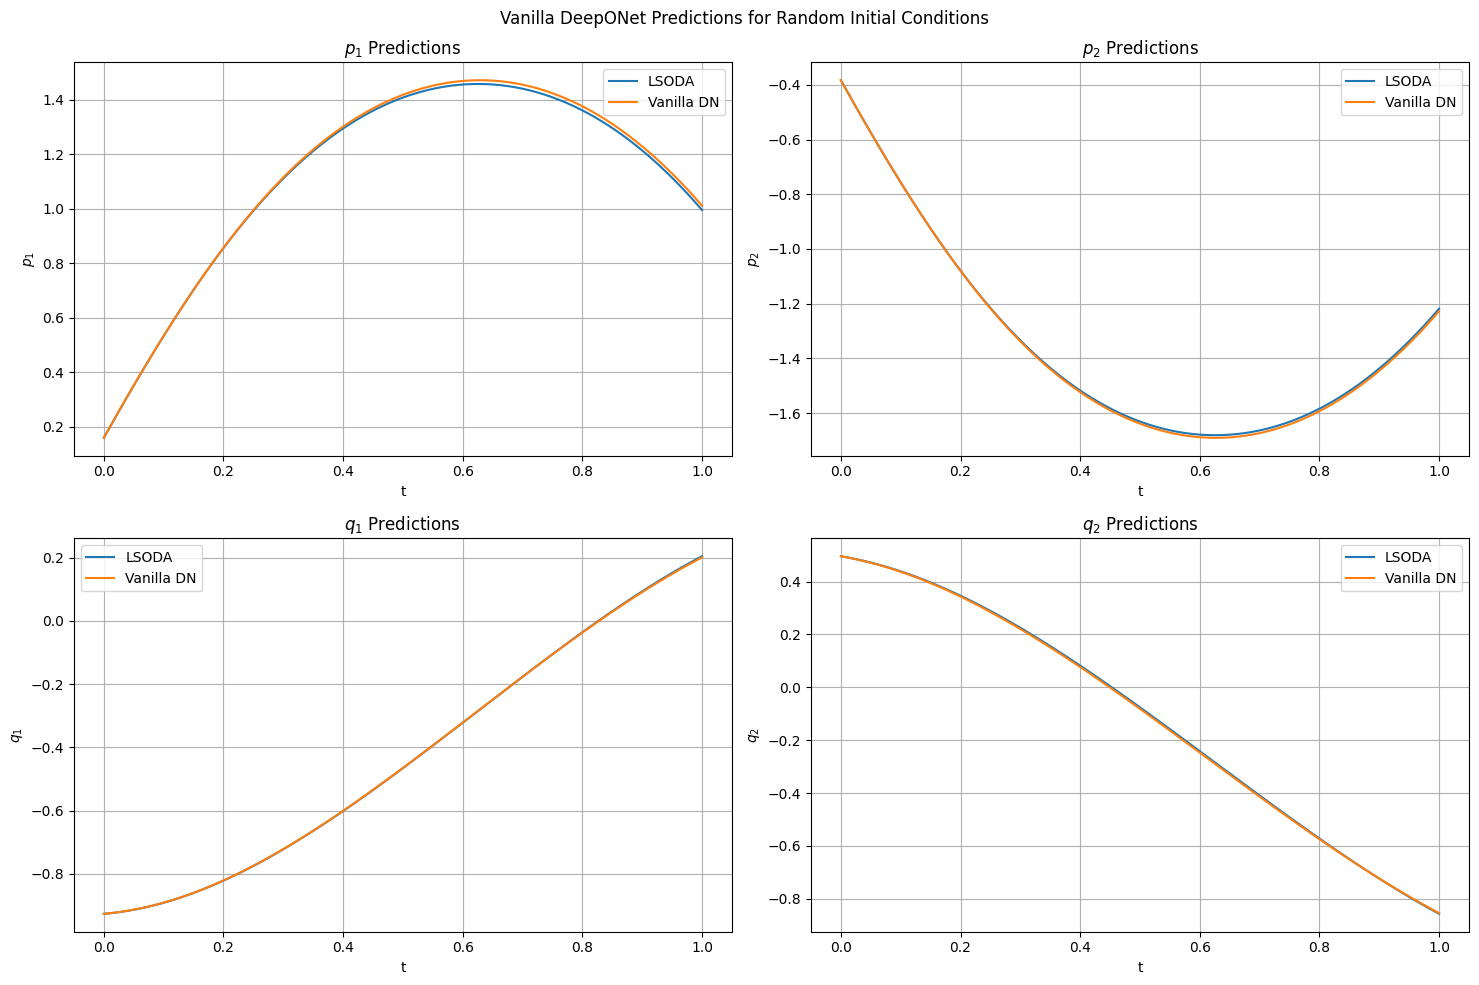

In [55]:
n = 500
t = np.linspace(t0, tfinal, n)

p1_init = np.random.uniform(-1.0, 1.0, size=(1,))
p2_init = np.random.uniform(-1.0, 1.0, size=(1,))
q1_init = np.random.uniform(-1.0, 1.0, size=(1,))
q2_init = np.random.uniform(-1.0, 1.0, size=(1,))
H_init = calc_H(p1_init, p2_init, q1_init, q2_init)
evals_init = calc_evals_pq(p1_init, p2_init, q1_init, q2_init)
e1_init, e2_init = evals_init[0], evals_init[1]


data_model = np.column_stack([p1_init, p2_init, q1_init, q2_init])
data_model = np.reshape(data_model, (-1,))
data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)

H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)

E_model = np.column_stack([e1_init, e2_init])
E_model = np.reshape(E_model, (-1,))
E_model = np.repeat(np.expand_dims(E_model, axis=0), n, axis=0)

H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
        
tHE_model = np.column_stack([t, H_model, E_model])

p1 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 0, params)
p2 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 1, params)
q1 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 2, params)
q2 = jax.vmap(var_model, [0, 0, None, None])(tHE_model, data_model, 3, params)


data_rk = np.column_stack([p1_init, p2_init, q1_init, q2_init])
data_rk = np.reshape(data_rk, (-1,))
t_rk = t
    
sol_rk = odeint(TodaLatt, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
p1_rk, p2_rk, q1_rk, q2_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3]
H_rk = calc_H(p1_rk, p2_rk, q1_rk, q2_rk)


fig = plt.figure(figsize=(15, 10))
fig.suptitle("Vanilla DeepONet Predictions for Random Initial Conditions")

plt.subplot(2, 2, 1)
plt.tight_layout()
plt.plot(t, p1_rk)
plt.plot(t, p1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_1$')
plt.title(r'$p_1$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])


plt.subplot(2, 2, 2)
plt.tight_layout()
plt.plot(t, p2_rk)
plt.plot(t, p2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_2$')
plt.title(r'$p_2$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])


plt.subplot(2, 2, 3)
plt.tight_layout()
plt.plot(t, q1_rk)
plt.plot(t, q1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_1$')
plt.title(r'$q_1$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])

plt.subplot(2, 2, 4)
plt.tight_layout()
plt.plot(t, q2_rk)
plt.plot(t, q2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_2$')
plt.title(r'$q_2$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])


#fig.savefig("Toda3_vanilla_preds_5000ep.png")

In [121]:
@jax.jit
def f_func_newton_eig(args, e_0) :

    args = jnp.reshape(args, (-1,))
    e_0 = jnp.reshape(e_0, (-1,))

    p1, p2, q1, q2 = args[0], args[1], args[2], args[3]
    e1_0, e2_0 = e_0[0], e_0[1]
    
    evals = calc_evals_pq(p1, p2, q1, q2)

    e1, e2 = evals[0], evals[1]

    f1 = e1 - e1_0
    f2 = e2 - e2_0

    f = jnp.array([[f1], [f2]])
    f = jnp.reshape(f, (2, 1))

    return f
    
#@jax.jit
def get_derivs_newton_eig(args, e_0, e, min) :

    a1, a2, b1, b2 = args[0], args[1], args[2], args[3]

    sqrt_d = jnp.sqrt((a1 - a2)**2 + 4*b1**2)

    if min == True :
        
        de_a1 = 1/2 - (a1 - a2)/(2*sqrt_d)
        de_a2 = 1/2 + (a1 - a2)/(2*sqrt_d)
        de_b1 = -2*b1/sqrt_d
        de_b2 = 0.0

    else :

        de_a1 = 1/2 + (a1 - a2)/(2*sqrt_d)
        de_a2 = 1/2 - (a1 - a2)/(2*sqrt_d)
        de_b1 = 2*b1/sqrt_d
        de_b2 = 0.0        

    df_a1 = de_a1
    df_a2 = de_a2
    df_b1 = de_b1
    df_b2 = de_b2

    df_x = (df_a1, df_a2, df_b1, df_b2)

    return df_x


@jax.jit
def gradf_func_newton_eig(args, e_0) :

    e_0 = jnp.reshape(e_0, (-1,))

    p1, p2, q1, q2 = args[0], args[1], args[2], args[3]
    e1_0, e2_0 = e_0[0], e_0[1]

    a1, a2, b1, b2 = calc_ab(p1, p2, q1, q2)
    args_new = (a1, a2, b1, b2)
    
    evals = calc_evals_pq(p1, p2, q1, q2)
    
    e1, e2 = evals[0], evals[1]
 
    df1_a1, df1_a2, df1_b1, df1_b2 = get_derivs_newton_eig(args_new, e1_0, e1, True)
    df2_a1, df2_a2, df2_b1, df2_b2 = get_derivs_newton_eig(args_new, e2_0, e2, False)

    df1_p1, df2_p1 = df1_a1*-0.5, df2_a1*-0.5
    df1_p2, df2_p2 = df1_a2*-0.5, df2_a2*-0.5

    df1_q1 = df1_b1*0.5*b1 + df1_b2*-0.5*b2
    df2_q1 = df2_b1*0.5*b1 + df2_b2*-0.5*b2

    df1_q2 = df1_b1*-0.5*b1 + df1_b2*0.5*b2
    df2_q2 = df2_b1*-0.5*b1 + df2_b2*0.5*b2


    gradf = jnp.array([[df1_p1, df1_p2, df1_q1, df1_q2],
                       [df2_p1, df2_p2, df2_q1, df2_q2]])
    

    gradf = jnp.reshape(gradf, (2, 4))
                    
    return gradf
    
@jax.jit

def newtons_eig_root(x, e_0) :

    iter_num = 0

    e_0 = jnp.reshape(e_0, (-1, 1))

    while iter_num < 5 :

        x = jnp.reshape(x, (-1, 1))
        
        F = f_func_newton_eig(x, e_0)
        J = gradf_func_newton_eig(x, e_0)
        J_inv = jnp.linalg.pinv(J)

        print(x.shape, F.shape, J.shape, J_inv.shape)

        x = x - J_inv@F

        iter_num = iter_num + 1

    return x

@jax.jit
def find_min_newton_eig(x, e_0) :

    return jnp.squeeze(jax.vmap(newtons_eig_root, (0, 0))(x, e_0))

In [122]:
x_test = jnp.array([[1.0, 2.0, 3.0, 4.0], [1.0, 2.0, 3.0, 4.0]])
e_test = jnp.array([[1.0, 2.0], [1.0, 2.0]])

print(calc_H(1.0, 2.0, 3.0, 4.0))

sol_newton_eig = find_min_newton_eig(x_test, e_test)

p1N, p2N, q1N, q2N = sol_newton_eig[0, 0], sol_newton_eig[0, 1], sol_newton_eig[0, 2], sol_newton_eig[0, 3]

print(p1N, p2N, q1N, q2N, calc_H(p1N, p2N, q1N, q2N))

5.586161269630487
(4, 1) (2, 1) (2, 4) (4, 2)
(4, 1) (2, 1) (2, 4) (4, 2)
(4, 1) (2, 1) (2, 4) (4, 2)
(4, 1) (2, 1) (2, 4) (4, 2)
(4, 1) (2, 1) (2, 4) (4, 2)
-3.707444744136047 -2.2925552558639524 3.152948115021419 3.847051884978581 12.001914094149557


In [88]:
@jax.jit
def f_func_newton_H(args, H_0) :

    args = jnp.reshape(args, (-1,))
    H_0 = jnp.reshape(H_0, (-1,))

    p1, p2, p3, q1, q2, q3 = args[0], args[1], args[2], args[3], args[4], args[5]
    H_0 = H_0[0]
    
    H = calc_H(p1, p2, p3, q1, q2, q3)

    f_val = H - H_0
    
    f = jnp.array([[f_val]])

    return f
    
@jax.jit
def gradf_func_newton_H(args, H_0) :

    args = jnp.reshape(args, (-1,))
    H_0 = jnp.reshape(H_0, (-1,))

    p1, p2, p3, q1, q2, q3 = args[0], args[1], args[2], args[3], args[4], args[5]
    H_0 = H_0[0]    

    dH_p1 = p1
    dH_p2 = p2
    dH_p3 = p3
    dH_q1 = jnp.exp(q1 - q2) - jnp.exp(q3 - q1)
    dH_q2 = -jnp.exp(q1 - q2) + jnp.exp(q2 - q3)
    dH_q3 = -jnp.exp(q2 - q3) + jnp.exp(q3 - q1)

    df_p1 = dH_p1
    df_p2 = dH_p2
    df_p3 = dH_p3
    df_q1 = dH_q1
    df_q2 = dH_q2
    df_q3 = dH_q3

    grad_f = jnp.array([[df_p1, df_p2, df_p3, df_q1, df_q2, df_q3]])

    return grad_f


@jax.jit
def newtons_H_root(x, H_0) :

    iter_num = 0

    H_0 = jnp.reshape(H_0, (-1, 1))

    while iter_num < 5 :

        x = jnp.reshape(x, (-1, 1))
        
        F = f_func_newton_H(x, H_0)
        J = gradf_func_newton_H(x, H_0)
        J_inv = jnp.linalg.pinv(J)

        x = x - J_inv@F

        iter_num = iter_num + 1

    return x

@jax.jit
def find_min_newton_H(x, H_0) :

    return jnp.squeeze(jax.vmap(newtons_H_root, (0, 0), 0)(x, H_0))

In [89]:
x_test = jnp.array([[1.0, 2.0, 3.0, 4.0, 5.0, 6.0], [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]])
H_test = jnp.array([[1.0], [1.0]])

print(calc_H(1.0, 2.0, 3.0, 4.0, 5.0, 6.0), calc_H(1.0, 2.0, 3.0, 4.0, 5.0, 6.0))

sol_newton_H = find_min_newton_H(x_test, H_test)

p1N, p2N, p3N, q1N, q2N, q3N = sol_newton_H[0, 0], sol_newton_H[0, 1], sol_newton_H[0, 2], sol_newton_H[0, 3], sol_newton_H[0, 4], sol_newton_H[0, 5]

print(p1N, p2N, p3N, q1N, q2N, q3N, calc_H(p1N, p2N, p3N, q1N, q2N, q3N))

15.124814981273536 15.124814981273536
0.468321103353259 0.9366422067065189 1.4049633100597783 3.9599804893094657 5.0 6.040019510690534 10.246949428506635


In [90]:
class HClosestPoint(nn.Module):

    H_0: float
    
    @nn.compact
    def __call__(self, inputs):
    
        x_min = find_min_newton_H(inputs, self.H_0)
    
        return x_min

In [91]:
class HCDeepONet(nn.Module):

  t0: float
  tfinal: float
  Hmin: float
  Hmax: float
  layers: int 
  units: int

  @nn.compact
  def __call__(self, tHE, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tHE.ndim == 1:
      tHE = jnp.reshape(tHE, (1,-1)) 

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    H_0_norm = Normalize(self.Hmin, self.Hmax)(H_0)
   
    p1_0 = u[:, :1]
    p2_0 = u[:, 1:2]
    p3_0 = u[:, 2:3]
    q1_0 = u[:, 3:4]
    q2_0 = u[:, 4:5]
    q3_0 = u[:, 5:]

    u = jnp.column_stack((p1_0, p2_0, p3_0, q1_0, q2_0, q3_0))

    # b = t_0_norm
    b = jnp.column_stack((t_0_norm, H_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_p1 = trunk_net[:, :self.units]
    trunk_p2 = trunk_net[:, self.units:2*self.units]
    trunk_p3 = trunk_net[:, 2*self.units:3*self.units]
    trunk_q1 = trunk_net[:, 3*self.units:4*self.units]
    trunk_q2 = trunk_net[:, 4*self.units:5*self.units]
    trunk_q3 = trunk_net[:, 5*self.units:]
      
    branch_p1 = branch_net[:, :self.units]
    branch_p2 = branch_net[:, self.units:2*self.units]
    branch_p3 = branch_net[:, 2*self.units:3*self.units]
    branch_q1 = branch_net[:, 3*self.units:4*self.units]
    branch_q2 = branch_net[:, 4*self.units:5*self.units]
    branch_q3 = branch_net[:, 5*self.units:]
      
    p1 = CombineBranches()(trunk_p1, branch_p1)
    p2 = CombineBranches()(trunk_p2, branch_p2)
    p3 = CombineBranches()(trunk_p3, branch_p3)
    q1 = CombineBranches()(trunk_q1, branch_q1)
    q2 = CombineBranches()(trunk_q2, branch_q2)
    q3 = CombineBranches()(trunk_q3, branch_q3)
      
    p1 = HardConstraint(self.t0, self.tfinal, p1_0)([t_0, p1])
    p2 = HardConstraint(self.t0, self.tfinal, p2_0)([t_0, p2])
    p3 = HardConstraint(self.t0, self.tfinal, p3_0)([t_0, p3])
    q1 = HardConstraint(self.t0, self.tfinal, q1_0)([t_0, q1])
    q2 = HardConstraint(self.t0, self.tfinal, q2_0)([t_0, q2])
    q3 = HardConstraint(self.t0, self.tfinal, q3_0)([t_0, q3])

    z = jnp.column_stack([p1, p2, p3, q1, q2, q3])
    z = HClosestPoint(H_0)(z)

    p1 = z[:1]
    p2 = z[1:2]
    p3 = z[2:3]
    q1 = z[3:4]
    q2 = z[4:5]
    q3 = z[5:]
      
    p1 = jnp.reshape(p1, (-1,))
    p2 = jnp.reshape(p2, (-1,))
    p3 = jnp.reshape(p3, (-1,))
    q1 = jnp.reshape(q1, (-1,))
    q2 = jnp.reshape(q2, (-1,))
    q3 = jnp.reshape(q3, (-1,))

    return p1, p2, p3, q1, q2, q3

In [92]:
@partial(jax.jit, static_argnums=(2,))
def HCvar_model(t, z, component, params):
  return HCdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def HCvar(t, z, component, params):
  return jax.vmap(HCvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def HCvar_t(t, z, component, params):
  return jax.vmap(jax.grad(HCvar_model, 0), [0, 0, None, None])(t, z, component, params)       
    
@jax.jit
def HCloss(params, tHE, z):
    
    p1_t_loss_w = 1.0
    p2_t_loss_w = 1.0
    p3_t_loss_w = 1.0
    q1_t_loss_w = 1.0
    q2_t_loss_w = 1.0
    q3_t_loss_w = 1.0    
    
    diff_loss_w = 1.0
    H_loss_w = 1.0

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:4]
    eval3_0 = tHE[:, 4:]
    
    p1_0 = z[:, :1]
    p2_0 = z[:, 1:2]
    p3_0 = z[:, 2:3]
    q1_0 = z[:, 3:4]
    q2_0 = z[:, 4:5]
    q3_0 = z[:, 5:]
    
    p1 = var(tHE, z, 0, params)
    p2 = var(tHE, z, 1, params)
    p3 = var(tHE, z, 2, params)
    q1 = var(tHE, z, 3, params)
    q2 = var(tHE, z, 4, params)
    q3 = var(tHE, z, 5, params)
    
    H = calc_H(p1, p2, p3, q1, q2, q3)
    H = jnp.reshape(H, (-1, 1))
    
    dp1_tHE = var_t(tHE, z, 0, params)
    dp2_tHE = var_t(tHE, z, 1, params)
    dp3_tHE = var_t(tHE, z, 2, params)
    dq1_tHE = var_t(tHE, z, 3, params)
    dq2_tHE = var_t(tHE, z, 4, params)
    dq3_tHE = var_t(tHE, z, 5, params)
        
    p1_t = dp1_tHE[:, 0]
    p2_t = dp2_tHE[:, 0]  
    p3_t = dp3_tHE[:, 0]
    q1_t = dq1_tHE[:, 0]
    q2_t = dq2_tHE[:, 0]
    q3_t = dq3_tHE[:, 0]
    
    H_loss = H - H_0
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)

    p1_t_loss = p1_t - (-jnp.exp(q1 - q2) + jnp.exp(q3 - q1))
    p1_t_loss = jnp.square(p1_t_loss)
    p1_t_loss = jnp.mean(p1_t_loss)

    q1_t_loss = q1_t - p1
    q1_t_loss = jnp.square(q1_t_loss)
    q1_t_loss = jnp.mean(q1_t_loss)
    
    p2_t_loss = p2_t - (jnp.exp(q1 - q2) - jnp.exp(q2 - q3))
    p2_t_loss = jnp.square(p2_t_loss)
    p2_t_loss = jnp.mean(p2_t_loss)
    
    q2_t_loss = q2_t - p2
    q2_t_loss = jnp.square(q2_t_loss)
    q2_t_loss = jnp.mean(q2_t_loss)

    p3_t_loss = p3_t - (jnp.exp(q2 - q3) - jnp.exp(q3 - q1))
    p3_t_loss = jnp.square(p3_t_loss)
    p3_t_loss = jnp.mean(p3_t_loss)
    
    q3_t_loss = q3_t - p3
    q3_t_loss = jnp.square(q3_t_loss)
    q3_t_loss = jnp.mean(q3_t_loss)
        
    diff_loss = p1_t_loss_w*p1_t_loss +  q1_t_loss_w*q1_t_loss + p2_t_loss_w*p2_t_loss + \
                q2_t_loss_w*q2_t_loss + p3_t_loss_w*p3_t_loss + q3_t_loss_w*q3_t_loss

    total_loss = diff_loss_w*diff_loss + H_loss_w*H_loss

    return total_loss
    
@jax.jit
def HCtrain_step(params, pdes, z):
    t = pdes[:, :]

    test = jax.value_and_grad(HCloss, has_aux = False)(params, t, z)
    
    return test

@partial(jax.jit, static_argnums=(3,))
def HCoptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [93]:
def HCtrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-4
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = HCtrain_step(params, des_batch.numpy(), z_batch.numpy())
            params, opt_state = HCoptimize(grads, opt_state, params, optimizer.update)
           
            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [94]:
HCdeeponet = HCDeepONet(t0, tfinal, Hmin, Hmax, layers=4, units=40)

t_init = jnp.full((10, 5), 1.0, dtype = jnp.float64)
u_init = jnp.full((10, 6), 1.0, dtype = jnp.float64)

HCparams = HCdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [95]:
HCparam_count = sum(x.size for x in jax.tree.leaves(HCparams))
print(HCparam_count)

26640


In [96]:
HCparams = copy.deepcopy(params)

batch size: 100
Loss in epoch 0: 0.0002137039275429493
Loss in epoch 100: 8.479860963696886e-05
Loss in epoch 200: 8.047993643380139e-05
Loss in epoch 300: 7.372234619380132e-05
Loss in epoch 400: 7.429560736204666e-05
Loss in epoch 500: 7.025414167567138e-05
Loss in epoch 600: 6.653482029073251e-05
Loss in epoch 700: 6.062060126751296e-05
Loss in epoch 800: 6.14650131623516e-05
Loss in epoch 900: 7.053686688318677e-05
Loss in epoch 1000: 5.7456261153771785e-05
Loss in epoch 1100: 5.4636213337590794e-05
Loss in epoch 1200: 5.43033526886153e-05
Loss in epoch 1300: 5.505277211128005e-05
Loss in epoch 1400: 5.194400406913817e-05
Loss in epoch 1500: 4.77908518936136e-05
Loss in epoch 1600: 5.109773752882445e-05
Loss in epoch 1700: 5.069116755261684e-05
Loss in epoch 1800: 4.527843721869938e-05
Loss in epoch 1900: 4.702087030776677e-05
Loss in epoch 2000: 4.518863012002435e-05
Loss in epoch 2100: 4.719274271023575e-05
Loss in epoch 2200: 4.319052341485193e-05
Loss in epoch 2300: 4.577377292

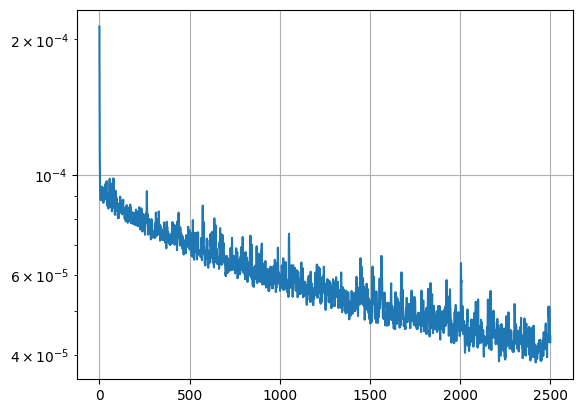

In [97]:
epochs = 2500
HCparams, HCloss = HCtrain_network(HCparams, de_points, zsensors, epochs)

plt.semilogy(HCloss)
plt.grid()

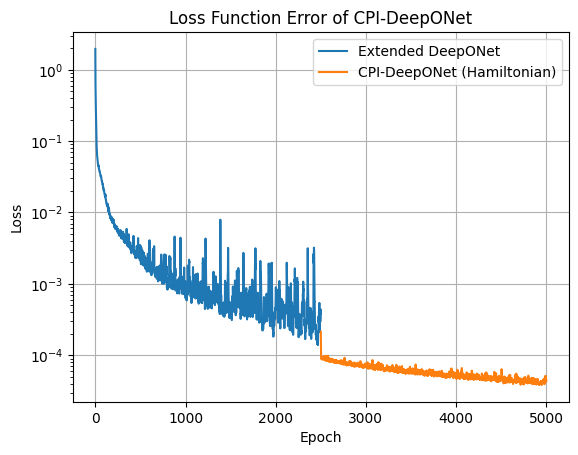

In [98]:
split = 2500
num_ep = np.arange(0, split, 1)
HCnum_ep = np.arange(split, split + epochs, 1)

plt.semilogy(num_ep, loss)
plt.semilogy(HCnum_ep, HCloss)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title("Loss Function Error of CPI-DeepONet")
plt.legend(['Extended DeepONet', 'CPI-DeepONet (Hamiltonian)'])
plt.grid()
#plt.savefig('Toda3_cpiH_loss_2500+2500ep.png')

In [109]:
class EClosestPoint(nn.Module):

    e_0: float
    
    @nn.compact
    def __call__(self, inputs):
    
        x_min = find_min_newton_eig(inputs, self.e_0)
    
        return x_min

In [110]:
class ECDeepONet(nn.Module):

  t0: float
  tfinal: float
  Hmin: float
  Hmax: float
  layers: int 
  units: int

  @nn.compact
  def __call__(self, tHE, u):

    if u.ndim == 1:
      u = jnp.reshape(u, (1,-1))

    if tHE.ndim == 1:
      tHE = jnp.reshape(tHE, (1,-1)) 

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:]
      
    t_0 = jnp.reshape(t_0, (-1,1))
    t_0_norm = Normalize(self.t0, self.tfinal)(t_0)

    H_0_norm = Normalize(self.Hmin, self.Hmax)(H_0)
   
    p1_0 = u[:, :1]
    p2_0 = u[:, 1:2]
    q1_0 = u[:, 2:3]
    q2_0 = u[:, 3:]

    u = jnp.column_stack((p1_0, p2_0, q1_0, q2_0))

    # b = t_0_norm
    b = jnp.column_stack((t_0_norm, H_0_norm))

    trunk_net = MLP(self.layers, self.units)(b)
    branch_net = MLP(self.layers, self.units)(u)

    trunk_p1 = trunk_net[:, :self.units]
    trunk_p2 = trunk_net[:, self.units:2*self.units]
    trunk_q1 = trunk_net[:, 2*self.units:3*self.units]
    trunk_q2 = trunk_net[:, 3*self.units:]

      
    branch_p1 = branch_net[:, :self.units]
    branch_p2 = branch_net[:, self.units:2*self.units]
    branch_q1 = branch_net[:, 2*self.units:3*self.units]
    branch_q2 = branch_net[:, 3*self.units:]

      
    p1 = CombineBranches()(trunk_p1, branch_p1)
    p2 = CombineBranches()(trunk_p2, branch_p2)
    q1 = CombineBranches()(trunk_q1, branch_q1)
    q2 = CombineBranches()(trunk_q2, branch_q2)
      
    p1 = HardConstraint(self.t0, self.tfinal, p1_0)([t_0, p1])
    p2 = HardConstraint(self.t0, self.tfinal, p2_0)([t_0, p2])
    q1 = HardConstraint(self.t0, self.tfinal, q1_0)([t_0, q1])
    q2 = HardConstraint(self.t0, self.tfinal, q2_0)([t_0, q2])

    z = jnp.column_stack([p1, p2, q1, q2])
    e_0 = jnp.column_stack([eval1_0, eval2_0])
      
    z = EClosestPoint(e_0)(z)

    p1 = z[:1]
    p2 = z[1:2]
    q1 = z[2:3]
    q2 = z[3:]
      
    p1 = jnp.reshape(p1, (-1,))
    p2 = jnp.reshape(p2, (-1,))
    q1 = jnp.reshape(q1, (-1,))
    q2 = jnp.reshape(q2, (-1,))

    return p1, p2, q1, q2

In [111]:
@partial(jax.jit, static_argnums=(2,))
def ECvar_model(t, z, component, params):
  return ECdeeponet.apply(params, t, z)[component][0]

@partial(jax.jit, static_argnums=(2,))
def ECvar(t, z, component, params):
  return jax.vmap(ECvar_model, [0, 0, None, None])(t, z, component, params)

@partial(jax.jit, static_argnums=(2,))
def ECvar_t(t, z, component, params):
  return jax.vmap(jax.grad(ECvar_model, 0), [0, 0, None, None])(t, z, component, params)       
    
@jax.jit
def ECloss(params, tHE, z):
    
    p1_t_loss_w = 1.0
    p2_t_loss_w = 1.0
    q1_t_loss_w = 1.0
    q2_t_loss_w = 1.0  
    
    diff_loss_w = 1.0
    H_loss_w = 1.0

    t_0 = tHE[:, :1]
    H_0 = tHE[:, 1:2]
    eval1_0 = tHE[:, 2:3]
    eval2_0 = tHE[:, 3:]
    
    p1_0 = z[:, :1]
    p2_0 = z[:, 1:2]
    q1_0 = z[:, 2:3]
    q2_0 = z[:, 3:]
 
    p1 = var(tHE, z, 0, params)
    p2 = var(tHE, z, 1, params)
    q1 = var(tHE, z, 2, params)
    q2 = var(tHE, z, 3, params)
    
    H = calc_H(p1, p2, q1, q2)
    H = jnp.reshape(H, (-1, 1))
    
    dp1_tHE = var_t(tHE, z, 0, params)
    dp2_tHE = var_t(tHE, z, 1, params)
    dq1_tHE = var_t(tHE, z, 2, params)
    dq2_tHE = var_t(tHE, z, 3, params)
        
    p1_t = dp1_tHE[:, 0]
    p2_t = dp2_tHE[:, 0]  
    q1_t = dq1_tHE[:, 0]
    q2_t = dq2_tHE[:, 0]
    
    H_loss = H - H_0
    H_loss = jnp.square(H_loss)
    H_loss = jnp.mean(H_loss)

    p1_t_loss = p1_t - (-jnp.exp(q1 - q2) + jnp.exp(q2 - q1))
    p1_t_loss = jnp.square(p1_t_loss)
    p1_t_loss = jnp.mean(p1_t_loss)

    q1_t_loss = q1_t - p1
    q1_t_loss = jnp.square(q1_t_loss)
    q1_t_loss = jnp.mean(q1_t_loss)
    
    p2_t_loss = p2_t - (jnp.exp(q1 - q2) - jnp.exp(q2 - q1))
    p2_t_loss = jnp.square(p2_t_loss)
    p2_t_loss = jnp.mean(p2_t_loss)
    
    q2_t_loss = q2_t - p2
    q2_t_loss = jnp.square(q2_t_loss)
    q2_t_loss = jnp.mean(q2_t_loss)
        
    diff_loss = p1_t_loss + p2_t_loss + q1_t_loss + q2_t_loss
    
    total_loss = diff_loss + H_loss

    return total_loss
    
@jax.jit
def ECtrain_step(params, pdes, z):
    t = pdes[:, :]

    test = jax.value_and_grad(ECloss, has_aux = False)(params, t, z)
    
    return test

@partial(jax.jit, static_argnums=(3,))
def ECoptimize(grads, opt_state, params, optimizer_update):
    updates, opt_state = optimizer_update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state

In [112]:
def ECtrain_network(params, des, sensors, epochs=100):

    N = de_points.shape[0]
    
    nr_batches = 10
    batch_size = len(des)//nr_batches
    
    print("batch size:", batch_size)
    
    lr = 1e-4
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(params)
    
    ds_z = tf.data.Dataset.from_tensor_slices(sensors)
    ds_de = tf.data.Dataset.from_tensor_slices(des)
    
    ds = tf.data.Dataset.zip((ds_de, ds_z))
    ds = ds.shuffle(N).batch(batch_size)
    
    epoch_loss = np.zeros(epochs)
    epoch_aux_loss = np.zeros(epochs)

    for i in range(epochs):

        for (des_batch, z_batch) in ds:

            loss, grads = ECtrain_step(params, des_batch.numpy(), z_batch.numpy())
            params, opt_state = ECoptimize(grads, opt_state, params, optimizer.update)
           
            epoch_loss[i] += loss

        epoch_loss[i] /= batch_size

        if i % 100  == 0:
            print(f'Loss in epoch {i}: {epoch_loss[i]}')

    return params, epoch_loss

In [113]:
ECdeeponet = ECDeepONet(t0, tfinal, Hmin, Hmax, layers=4, units=40)

t_init = jnp.full((10, 4), 1.0, dtype = jnp.float64)
u_init = jnp.full((10, 4), 1.0, dtype = jnp.float64)

ECparams = ECdeeponet.init(jax.random.PRNGKey(0), t_init, u_init)

In [114]:
ECparam_count = sum(x.size for x in jax.tree.leaves(ECparams))
print(ECparam_count)

26560


In [115]:
ECparams = copy.deepcopy(params)

batch size: 100
Loss in epoch 0: 6.206618729748289e-05
Loss in epoch 100: 6.390235631785672e-06
Loss in epoch 200: 9.09322543503458e-06
Loss in epoch 300: 5.87033532102281e-06
Loss in epoch 400: 4.3808992198851194e-06


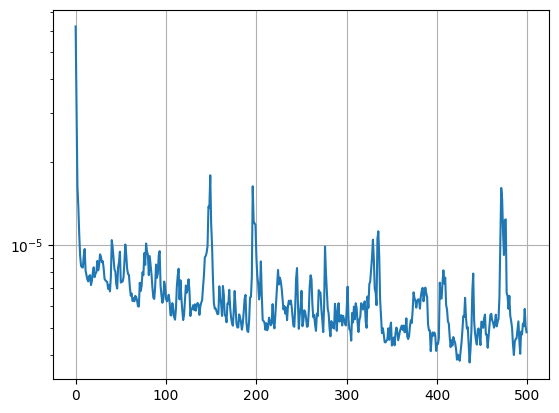

In [116]:
epochs = 500
ECparams, ECloss = ECtrain_network(ECparams, de_points, zsensors, epochs)

plt.semilogy(ECloss)
plt.grid()

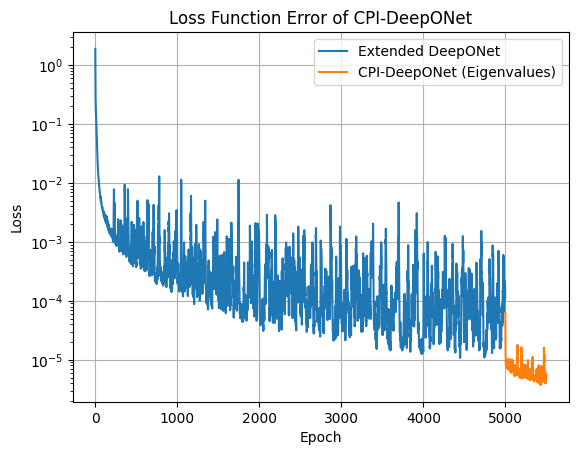

In [117]:
split = 5000
num_ep = np.arange(0, split, 1)
ECnum_ep = np.arange(split, split + epochs, 1)

plt.semilogy(num_ep, loss)
plt.semilogy(ECnum_ep, ECloss)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title("Loss Function Error of CPI-DeepONet")
plt.legend(['Extended DeepONet', 'CPI-DeepONet (Eigenvalues)'])
plt.grid()
#plt.savefig('Toda3_cpiE_loss_2500+2500ep.png')

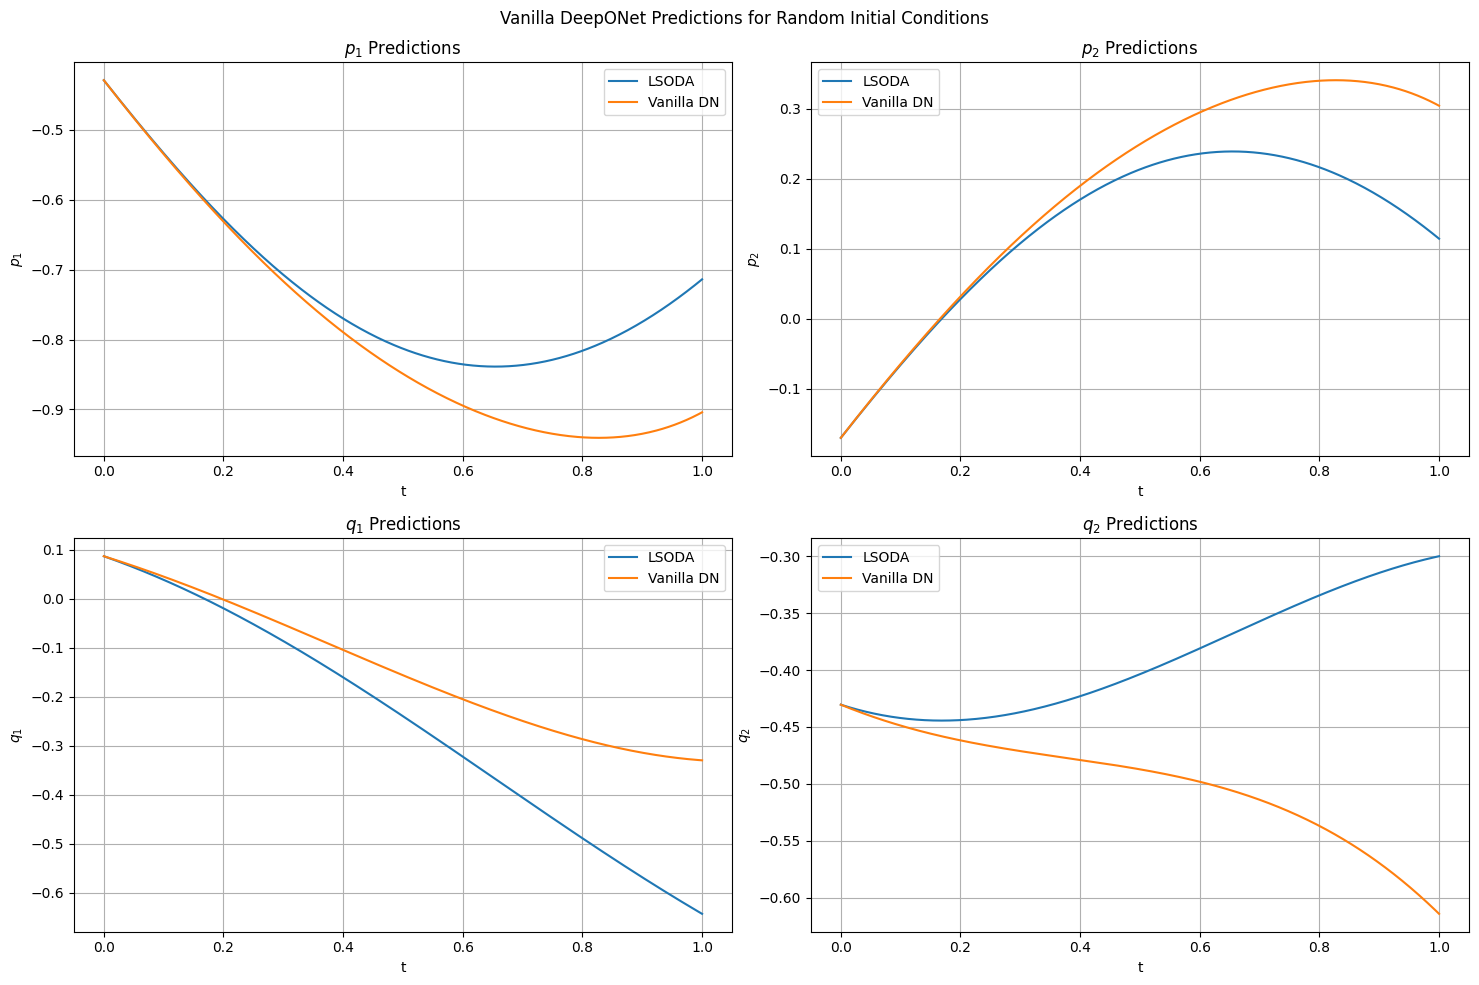

In [119]:
n = 500
t = np.linspace(t0, tfinal, n)

p1_init = np.random.uniform(-1.0, 1.0, size=(1,))
p2_init = np.random.uniform(-1.0, 1.0, size=(1,))
q1_init = np.random.uniform(-1.0, 1.0, size=(1,))
q2_init = np.random.uniform(-1.0, 1.0, size=(1,))
H_init = calc_H(p1_init, p2_init, q1_init, q2_init)
evals_init = calc_evals_pq(p1_init, p2_init, q1_init, q2_init)
e1_init, e2_init = evals_init[0], evals_init[1]


data_model = np.column_stack([p1_init, p2_init, q1_init, q2_init])
data_model = np.reshape(data_model, (-1,))
data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)

H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)

E_model = np.column_stack([e1_init, e2_init])
E_model = np.reshape(E_model, (-1,))
E_model = np.repeat(np.expand_dims(E_model, axis=0), n, axis=0)

H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
        
tHE_model = np.column_stack([t, H_model, E_model])

p1 = jax.vmap(ECvar_model, [0, 0, None, None])(tHE_model, data_model, 0, ECparams)
p2 = jax.vmap(ECvar_model, [0, 0, None, None])(tHE_model, data_model, 1, ECparams)
q1 = jax.vmap(ECvar_model, [0, 0, None, None])(tHE_model, data_model, 2, ECparams)
q2 = jax.vmap(ECvar_model, [0, 0, None, None])(tHE_model, data_model, 3, ECparams)


data_rk = np.column_stack([p1_init, p2_init, q1_init, q2_init])
data_rk = np.reshape(data_rk, (-1,))
t_rk = t
    
sol_rk = odeint(TodaLatt, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
p1_rk, p2_rk, q1_rk, q2_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3]
H_rk = calc_H(p1_rk, p2_rk, q1_rk, q2_rk)


fig = plt.figure(figsize=(15, 10))
fig.suptitle("Vanilla DeepONet Predictions for Random Initial Conditions")

plt.subplot(2, 2, 1)
plt.tight_layout()
plt.plot(t, p1_rk)
plt.plot(t, p1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_1$')
plt.title(r'$p_1$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])


plt.subplot(2, 2, 2)
plt.tight_layout()
plt.plot(t, p2_rk)
plt.plot(t, p2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_2$')
plt.title(r'$p_2$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])


plt.subplot(2, 2, 3)
plt.tight_layout()
plt.plot(t, q1_rk)
plt.plot(t, q1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_1$')
plt.title(r'$q_1$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])

plt.subplot(2, 2, 4)
plt.tight_layout()
plt.plot(t, q2_rk)
plt.plot(t, q2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_2$')
plt.title(r'$q_2$' + ' Predictions')
plt.legend(['LSODA', 'Vanilla DN'])


#fig.savefig("Toda3_vanilla_preds_5000ep.png")

Exp 0
1
Exp 1
1
Exp 2
1
Exp 3
1
Exp 4
1


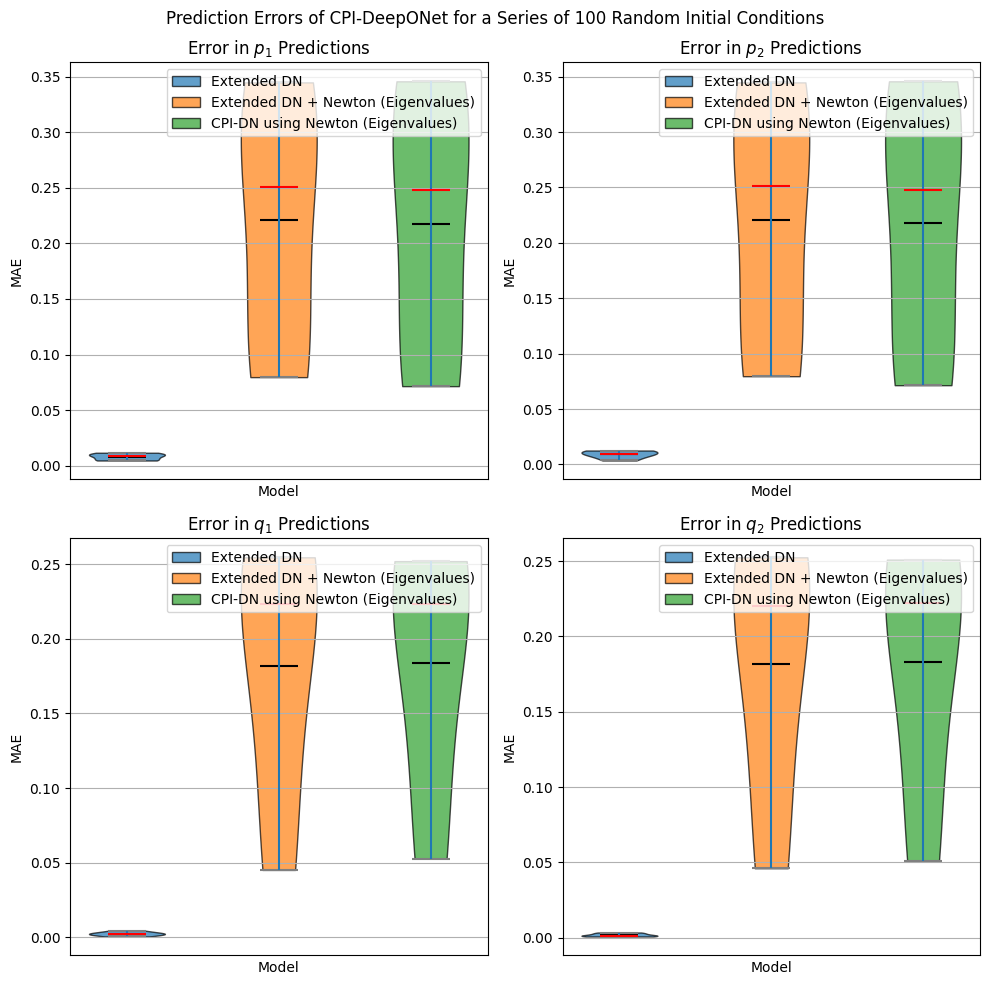

In [120]:
def run_test(num_vars, num_models, num_exp, models_lst, params_lst, labels_lst, bfgs_lst, newton_H_lst, newton_eig_lst) :

    n = 500
    t = np.linspace(t0, tfinal, n)
    
    
    preds = np.zeros((num_exp, num_models, num_vars, n))
    preds_error = np.zeros((num_exp, num_models, num_vars))

    for i in range(num_exp) :

        print("Exp", i)

        p1_init = np.random.uniform(-1.0, 1.0, size=(1,))
        p2_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q1_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q2_init = np.random.uniform(-1.0, 1.0, size=(1,))
        H_init = calc_H(p1_init, p2_init, q1_init, q2_init)
        evals_init = calc_evals_pq(p1_init, p2_init, q1_init, q2_init)
        e1_init, e2_init = evals_init[0], evals_init[1]
        
        
        data_model = np.column_stack([p1_init, p2_init, q1_init, q2_init])
        data_model = np.reshape(data_model, (-1,))
        data_model = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)
        
        H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
        
        E_model = np.column_stack([e1_init, e2_init])
        E_model = np.reshape(E_model, (-1,))
        E_model = np.repeat(np.expand_dims(E_model, axis=0), n, axis=0)
        
        H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
                
        tHE_model = np.column_stack([t, H_model, E_model])
                
        data_rk = np.column_stack([p1_init, p2_init, q1_init, q2_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = t
            
        sol_rk = odeint(TodaLatt, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        p1_rk, p2_rk, q1_rk, q2_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3]
        H_rk = calc_H(p1_rk, p2_rk, q1_rk, q2_rk)
        

        for j in range(num_models) :

            model = models_lst[j]
            params = params_lst[j]

            for k in range(num_vars - 1) :


                val = jax.vmap(model, [0, 0, None, None])(tHE_model, data_model, k, params)
                preds[i, j, k] = val

                
            preds[i, j, 4] = calc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3])

            # if j in bfgs_lst :
                
            #     args_arr = np.column_stack([preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3]])
                
            #     H_arr = tH_model[:, 1:]
        
            #     xbfgs = find_min_bfgs(args_arr, H_arr)                

            #     for l in range(4) :

            #         preds[i, j, l] = xbfgs[:, l]

                
            #     preds[i, j, 4] = Hcalc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3])  


            if j in newton_H_lst :
                
                args_arr = np.column_stack([preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3]])
                
                H_arr = tHE_model[:, 1:2]
            
                xnewtonH = find_min_newton_H(args_arr, H_arr)                
            
                for l in range(num_vars - 1) :
            
                    preds[i, j, l] = xnewtonH[:, l]
            
                
                preds[i, j, 4] = calc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3])
            
            
            if j in newton_eig_lst :

                print(j)
                
                args_arr = np.column_stack([preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3]])
                
                E_arr = tHE_model[:, 2:]
            
                xnewtoneig = find_min_newton_eig(args_arr, E_arr)                
            
                for l in range(num_vars - 1) :
            
                    preds[i, j, l] = xnewtoneig[:, l]
            
                
                preds[i, j, 4] = calc_H(preds[i, j, 0], preds[i, j, 1], preds[i, j, 2], preds[i, j, 3])
              

            for m in range(num_vars - 1) :

                preds_error[i, j, m] = np.mean(np.abs(sol_rk[:, m] - preds[i, j, m]))

            preds_error[i, j, 4] = np.mean(np.abs(H_rk - preds[i, j, 4]))
            


    x_labels = [r'$p_1$', r'$p_2$', r'$q_1$', r'$q_2$', 'H'] 
        
    # Set up the figure
    fig = plt.figure(figsize=(10, 10))
    fig.suptitle('Prediction Errors of CPI-DeepONet for a Series of 100 Random Initial Conditions')
    
    # Define colors for each model (adjust color palette as needed)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']   # Example colors for each model
    
    for j in range(num_vars - 1):
        plt.subplot(2, 2, j + 1)


        q1 = np.percentile(preds_error[:, 0, j], 25)
        q3 = np.percentile(preds_error[:, 0, j], 75)
        iqr = q3 - q1

        #plt.ylim(0.0, q3 + 1.5 * iqr)
        
        # Prepare data for each model for the current variable (j)
        data = [preds_error[:, alpha, j] for alpha in range(num_models)]
        
        # Create the violin plot with custom colors
        vp = plt.violinplot(data, positions=range(num_models), showmeans=True, showmedians=True)
        
        # Customize the colors of the violins
        for i in range(num_models):
            vp['bodies'][i].set_facecolor(colors[i])  # Set face color for each model
            vp['bodies'][i].set_edgecolor('black')   # Set edge color for each model
            vp['bodies'][i].set_alpha(0.7)            # Set transparency
        
        # Customize mean and median lines
        vp['cmeans'].set_color('black')  # Mean line color
        vp['cmedians'].set_color('red')
        vp['cmins'].set_color('gray')
        vp['cmaxes'].set_color('gray')# Median line color
    
        # Add labels, title, and grid
        plt.ylabel("MAE")
        if j == 4:
            plt.title("Error in " + x_labels[j] + " from Predictions")
        else:
            plt.title("Error in " + x_labels[j] + " Predictions")
        plt.grid(True, axis='y')
    
        # Add legend (outside the plot)
        plt.xticks([])  # Remove vertical axis ticks
        plt.xlabel("Model")  # Remove vertical axis label
        plt.legend(labels=labels_lst, loc='upper right')
    
    # Adjust the layout and display the plot
    plt.tight_layout()
    plt.show()
    

    
    #fig.savefig('Toda3_cpi_violinmae_2500+2500ep.png')
    return preds, preds_error, (p1_rk, p2_rk, q1_rk, q2_rk, H_rk)


preds, preds_error, (p1_rk, p2_rk, q1_rk, q2_rk, H_rk) = run_test(num_vars = 5, num_models = 3, num_exp = 5, \
         models_lst = [var_model, var_model, ECvar_model], \
         params_lst = [params, params, ECparams], \
         labels_lst = ['Extended DN', 'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Eigenvalues)'], \
         bfgs_lst = [], 
         newton_H_lst = [],
         newton_eig_lst = [1])

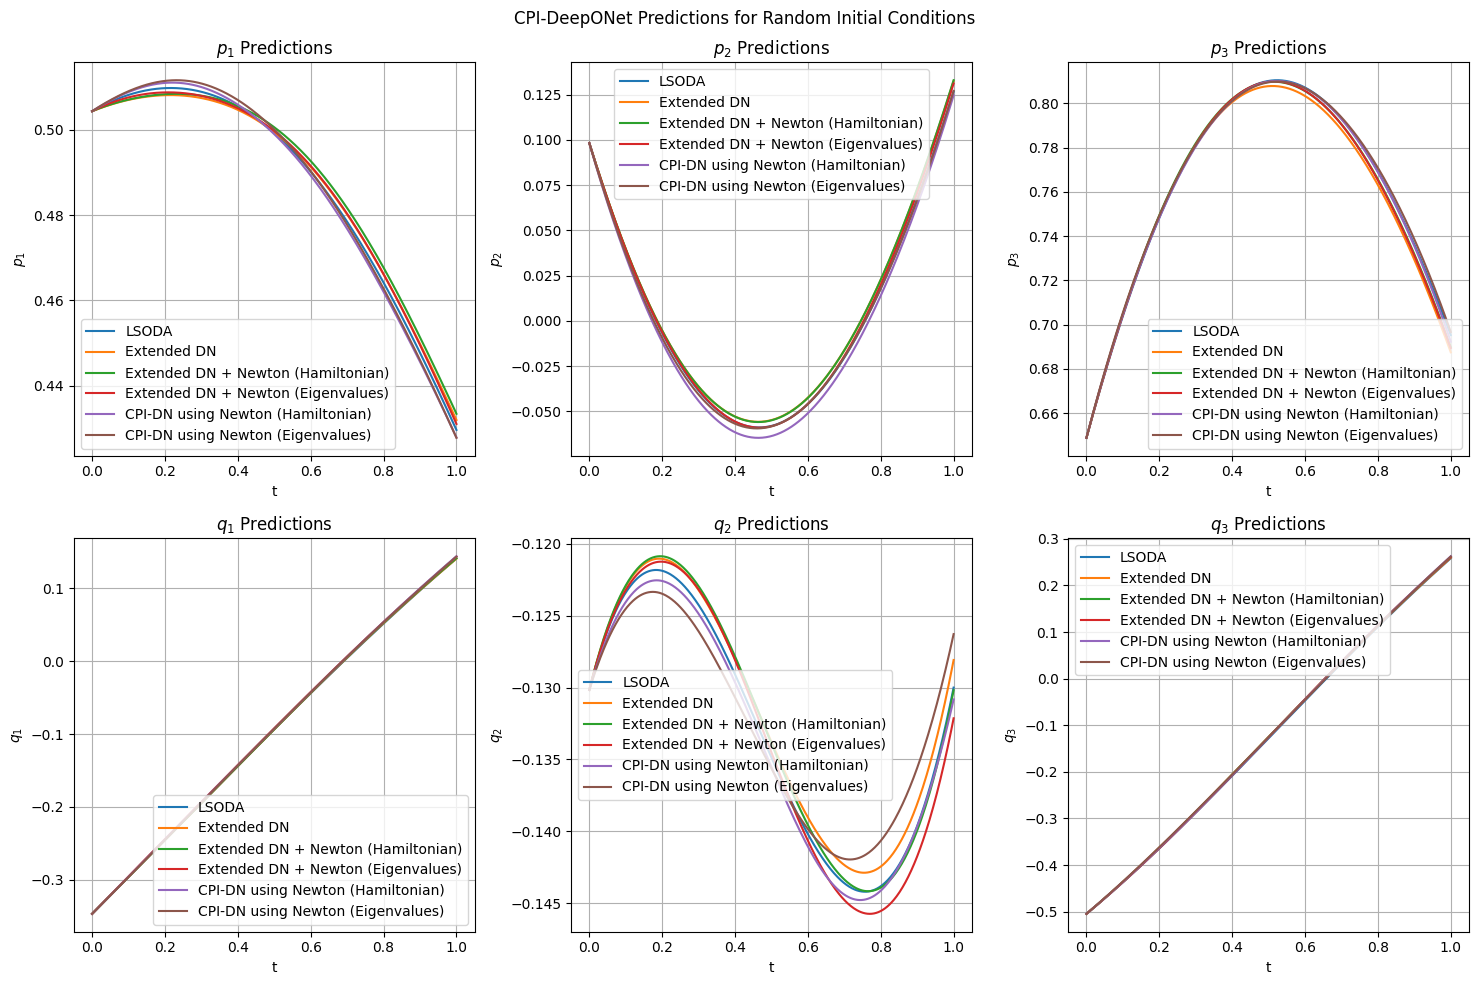

In [119]:
n = 500
t_tot = np.linspace(t0, tfinal, n)
model_no = -1
p1, p2, p3, q1, q2, q3, H = preds[model_no, 0, 0, :], preds[model_no, 0, 1, :], preds[model_no, 0, 2, :], \
                            preds[model_no, 0, 3, :], preds[model_no, 0, 4, :], preds[model_no, 0, 5, :], \
                            preds[model_no, 0, 6, :]

Hp1, Hp2, Hp3, Hq1, Hq2, Hq3, HH = preds[model_no, 1, 0, :], preds[model_no, 1, 1, :], preds[model_no, 1, 2, :], \
                                   preds[model_no, 1, 3, :], preds[model_no, 1, 4, :], preds[model_no, 1, 5, :], \
                                   preds[model_no, 1, 6, :]

Ep1, Ep2, Ep3, Eq1, Eq2, Eq3, EH = preds[model_no, 2, 0, :], preds[model_no, 2, 1, :], preds[model_no, 2, 2, :], \
                                   preds[model_no, 2, 3, :], preds[model_no, 2, 4, :], preds[model_no, 2, 5, :], \
                                   preds[model_no, 2, 6, :]


HCp1, HCp2, HCp3, HCq1, HCq2, HCq3, HCH = preds[model_no, 3, 0, :], preds[model_no, 3, 1, :], preds[model_no, 3, 2, :], \
                                          preds[model_no, 3, 3, :], preds[model_no, 3, 4, :], preds[model_no, 3, 5, :], \
                                          preds[model_no, 3, 6, :]


ECp1, ECp2, ECp3, ECq1, ECq2, ECq3, ECH = preds[model_no, 4, 0, :], preds[model_no, 4, 1, :], preds[model_no, 4, 2, :], \
                                          preds[model_no, 4, 3, :], preds[model_no, 4, 4, :], preds[model_no, 4, 5, :], \
                                          preds[model_no, 4, 6, :]



fig = plt.figure(figsize=(15, 10))
fig.suptitle("CPI-DeepONet Predictions for Random Initial Conditions")

plt.subplot(2, 3, 1)
plt.tight_layout()
plt.plot(t_tot, p1_rk)
plt.plot(t_tot, p1)
plt.plot(t_tot, Hp1)
plt.plot(t_tot, Ep1)
plt.plot(t_tot, HCp1)
plt.plot(t_tot, ECp1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_1$')
plt.title(r'$p_1$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])


plt.subplot(2, 3, 2)
plt.tight_layout()
plt.plot(t_tot, p2_rk)
plt.plot(t_tot, p2)
plt.plot(t_tot, Hp2)
plt.plot(t_tot, Ep2)
plt.plot(t_tot, HCp2)
plt.plot(t_tot, ECp2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_2$')
plt.title(r'$p_2$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 3)
plt.tight_layout()
plt.plot(t_tot, p3_rk)
plt.plot(t_tot, p3)
plt.plot(t_tot, Hp3)
plt.plot(t_tot, Ep3)
plt.plot(t_tot, HCp3)
plt.plot(t_tot, ECp3)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_3$')
plt.title(r'$p_3$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 4)
plt.tight_layout()
plt.plot(t_tot, q1_rk)
plt.plot(t_tot, q1)
plt.plot(t_tot, Hq1)
plt.plot(t_tot, Eq1)
plt.plot(t_tot, HCq1)
plt.plot(t_tot, ECq1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_1$')
plt.title(r'$q_1$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 5)
plt.tight_layout()
plt.plot(t_tot, q2_rk)
plt.plot(t_tot, q2)
plt.plot(t_tot, Hq2)
plt.plot(t_tot, Eq2)
plt.plot(t_tot, HCq2)
plt.plot(t_tot, ECq2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_2$')
plt.title(r'$q_2$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 6)
plt.tight_layout()
plt.plot(t_tot, q3_rk)
plt.plot(t_tot, q3)
plt.plot(t_tot, Hq3)
plt.plot(t_tot, Eq3)
plt.plot(t_tot, HCq3)
plt.plot(t_tot, ECq3)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_3$')
plt.title(r'$q_3$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
           'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

#fig.savefig('Toda3_cpi_preds_2500+2500ep.png')

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


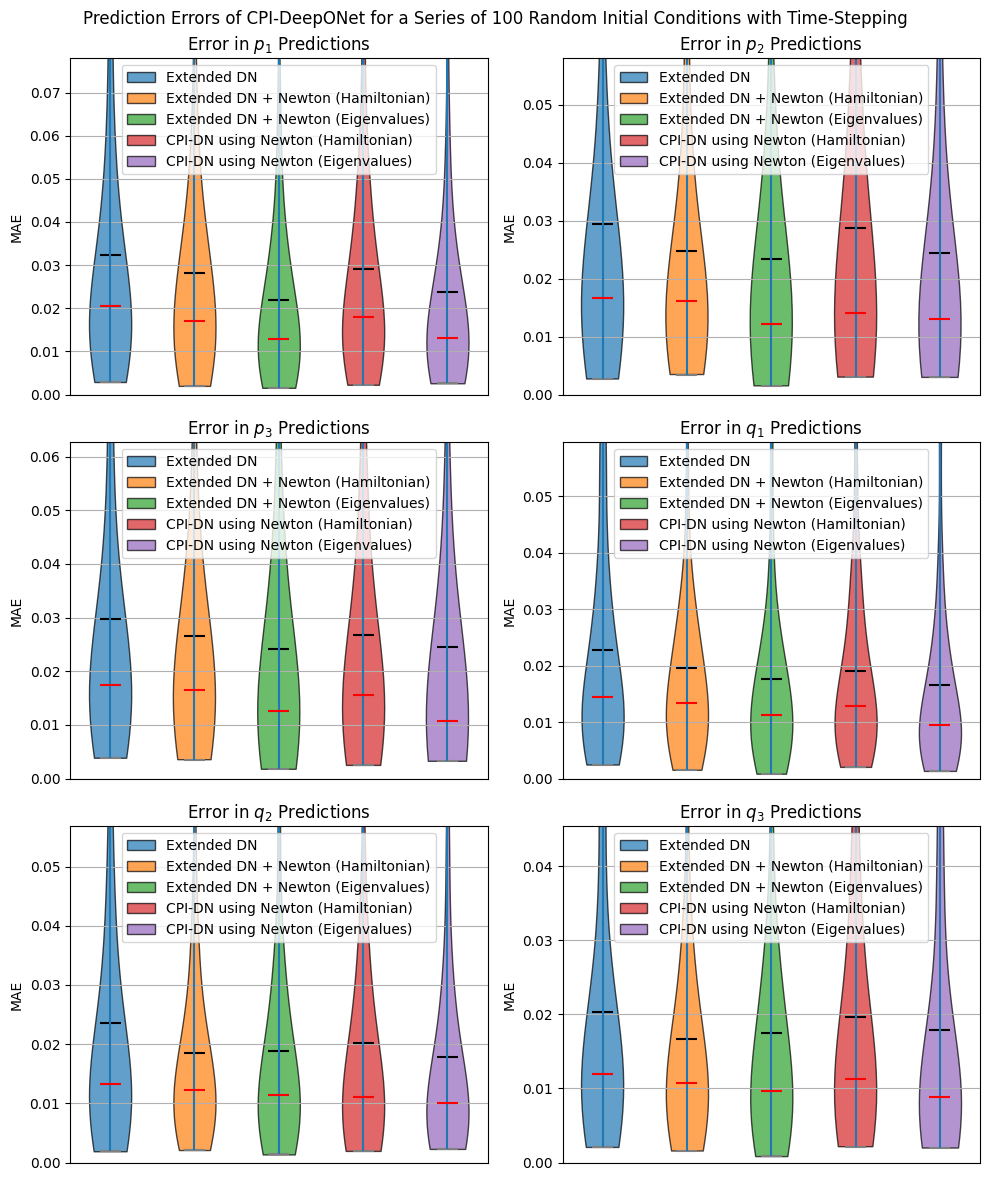

In [124]:
def tt_run_test(num_vars, num_models, num_exp, models_lst, params_lst, labels_lst, newton_H_lst, newton_eig_lst, bfgs_lst, t_end) :

    n = 500

    num_cycles = int(t_end/tfinal)
    n_ts = n*num_cycles
    t_step = tfinal/n

    
    preds = np.zeros((num_exp, num_models, num_cycles, num_vars, n))
    preds_error = np.zeros((num_exp, num_models, num_vars))

    for i in range(num_exp) :

        print(i)

        p1_init = np.random.uniform(-1.0, 1.0, size=(1,))
        p2_init = np.random.uniform(-1.0, 1.0, size=(1,))
        p3_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q1_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q2_init = np.random.uniform(-1.0, 1.0, size=(1,))
        q3_init = np.random.uniform(-1.0, 1.0, size=(1,))
        H_init = calc_H(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)
        evals_init = calc_evals_pq(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)
        e1_init, e2_init, e3_init = evals_init[0], evals_init[1], evals_init[2]
        
        data_model = np.column_stack([p1_init, p2_init, p3_init, q1_init, q2_init, q3_init])
        data_model = np.reshape(data_model, (-1,))
        data_model_0 = np.repeat(np.expand_dims(data_model, axis=0), n, axis=0)

        H_model = np.repeat(np.expand_dims(H_init, axis=0), n, axis=0)
        
        E_model = np.column_stack([e1_init, e2_init, e3_init])
        E_model = np.reshape(E_model, (-1,))
        E_model = np.repeat(np.expand_dims(E_model, axis=0), n, axis=0)

        t = np.linspace(t0, tfinal, n)
                
        tHE_model_0 = np.column_stack([t, H_model, E_model])
                        
        data_rk = np.column_stack([p1_init, p2_init, p3_init, q1_init, q2_init, q3_init])
        data_rk = np.reshape(data_rk, (-1,))
        t_rk = np.linspace(t0, t_end, n_ts)
        
        sol_rk = odeint(TodaLatt, data_rk, t_rk, rtol = 1e-13, atol = 1e-13)
        p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk = sol_rk[:, 0], sol_rk[:, 1], sol_rk[:, 2], sol_rk[:, 3], sol_rk[:, 4], sol_rk[:, 5]
        H_rk = calc_H(p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk)
        

        for j in range(num_models) :

            model = models_lst[j]
            params = params_lst[j]


            for c in range(num_cycles) :

                if c != 0 :

                    p1_init = preds[i, j, c - 1, 0, -1]
                    p2_init = preds[i, j, c - 1, 1, -1]
                    p3_init = preds[i, j, c - 1, 2, -1]
                    q1_init = preds[i, j, c - 1, 3, -1]
                    q2_init = preds[i, j, c - 1, 4, -1]
                    q3_init = preds[i, j, c - 1, 5, -1]
                    H_init = calc_H(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)
                    evals_init = calc_evals_pq(p1_init, p2_init, p3_init, q1_init, q2_init, q3_init)
                    e1_init, e2_init, e3_init = evals_init[0], evals_init[1], evals_init[2]
                    
                    data_model = np.column_stack([p1_init, p2_init, p3_init, q1_init, q2_init, q3_init])
                    data_model = np.reshape(data_model, (-1,))
                    data_model = np.repeat(np.expand_dims(data_model, axis=0), n + 1, axis=0)
            
                    H_model = np.repeat(np.expand_dims(H_init, axis=0), n + 1, axis=0)
                    
                    E_model = np.column_stack([e1_init, e2_init, e3_init])
                    E_model = np.reshape(E_model, (-1,))
                    E_model = np.repeat(np.expand_dims(E_model, axis=0), n + 1, axis=0)

                    t = np.linspace(t0, tfinal + t_step, n + 1)
                            
                    tHE_model = np.column_stack([t, H_model, E_model])  

                else:

                    data_model = data_model_0
                    tHE_model = tHE_model_0

                
                for k in range(num_vars - 1) :
    
                    val = jax.vmap(model, [0, 0, None, None])(tHE_model, data_model, k, params)

                    if c != 0 :
                        preds[i, j, c, k] = val[1:]

                    else:
                        preds[i, j, c, k] = val                        
    
                preds[i, j, c, 6] = calc_H(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], \
                                           preds[i, j, c, 3], preds[i, j, c, 4], preds[i, j, c, 5])



                if j in newton_H_lst :
                    
                    args_arr = np.column_stack([preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], \
                                                preds[i, j, c, 3], preds[i, j, c, 4], preds[i, j, c, 5]])
                    
                    H_arr = tHE_model[:, 1:2] if c == 0 else tHE_model[1:, 1:2]
            
                    xnewtonH = find_min_newton_H(args_arr, H_arr)                
    
                    for l in range(num_vars - 1) :
    
                        preds[i, j, c, l] = xnewtonH[:, l]
    
                    
                    preds[i, j, c, 6] = calc_H(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], \
                                               preds[i, j, c, 3], preds[i, j, c, 4], preds[i, j, c, 5])


                if j in newton_eig_lst :
                    
                    args_arr = np.column_stack([preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], \
                                                preds[i, j, c, 3], preds[i, j, c, 4], preds[i, j, c, 5]])
                    
                    E_arr = tHE_model[:, 2:] if c == 0 else tHE_model[1:, 2:]
            
                    xnewtoneig = find_min_newton_eig(args_arr, E_arr)                
    
                    for l in range(num_vars - 1) :
    
                        preds[i, j, c, l] = xnewtoneig[:, l]
    
                    
                    preds[i, j, c, 6] = calc_H(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], \
                                               preds[i, j, c, 3], preds[i, j, c, 4], preds[i, j, c, 5])

                   
                # if j in bfgs_lst :
                    
                #     args_arr = np.column_stack([preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3]])
                    
                #     E_arr = tE_model[:, 1:] if c == 0 else tE_model[1:, 1:]
            
                #     xbfgs = find_min_bfgs(args_arr, E_arr)                
    
                #     for l in range(num_vars - 1) :
    
                #         preds[i, j, c, l] = xbfgs[:, l]
    
                    
                #     preds[i, j, c, 4] = calc_E(preds[i, j, c, 0], preds[i, j, c, 1], preds[i, j, c, 2], preds[i, j, c, 3])  
                  
    
            for m in range(num_vars - 1) :
    
                preds_error[i, j, m] = np.mean(np.abs(sol_rk[:, m] - preds[i, j, :, m].flatten()))
    
            preds_error[i, j, 6] = np.mean(np.abs(H_rk - preds[i, j, :, 6].flatten()))
            


    x_labels = [r'$p_1$', r'$p_2$', r'$p_3$', r'$q_1$', r'$q_2$', r'$q_3$', 'H'] 
        
    fig = plt.figure(figsize=(10, 12))
    fig.suptitle('Prediction Errors of CPI-DeepONet for a Series of 100 Random Initial Conditions with Time-Stepping')
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for j in range(num_vars - 1):
        
        plt.subplot(3, 2, j + 1)

        q1 = np.percentile(preds_error[:, 0, j], 25)
        q3 = np.percentile(preds_error[:, 0, j], 75)
        iqr = q3 - q1

        plt.ylim(0.0, q3 + 1.5 * iqr) 
        
        data = [preds_error[:, alpha, j] for alpha in range(num_models)]
        
        vp = plt.violinplot(data, positions=range(num_models), showmeans=True, showmedians=True)
        
        for i in range(num_models):
            vp['bodies'][i].set_facecolor(colors[i])  # Set face color for each model
            vp['bodies'][i].set_edgecolor('black')   # Set edge color for each model
            vp['bodies'][i].set_alpha(0.7)            # Set transparency
        
        vp['cmeans'].set_color('black')
        vp['cmedians'].set_color('red')
        vp['cmins'].set_color('gray')
        vp['cmaxes'].set_color('gray')
    
        plt.ylabel("MAE")
        if j == 6:
            plt.title("Error in " + x_labels[j] + " from Predictions")
        else:
            plt.title("Error in " + x_labels[j] + " Predictions")
        plt.grid(True, axis='y')
    
        plt.xticks([])  
        plt.xlabel("")  
        plt.legend(labels=labels_lst)
        
    plt.tight_layout()
    plt.show()
    

    fig.savefig('Toda3_tt5.0_violinmae_2500+2500ep_100exps.png')
    return preds, preds_error, (p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk, H_rk)


t_end_val = 5.0

preds, preds_error, (p1_rk, p2_rk, p3_rk, q1_rk, q2_rk, q3_rk, H_rk) = tt_run_test(num_vars = 7, num_models = 5, num_exp = 100, \
                                       models_lst = [var_model, var_model, var_model, HCvar_model, ECvar_model], \
                                       params_lst = [params_5000ep, params_5000ep, params_5000ep, HCparams, ECparams], \
                                       labels_lst = ['Extended DN', 'Extended DN + Newton (Hamiltonian)', 'Extended DN + Newton (Eigenvalues)', \
                                                     'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'], \
                                       bfgs_lst = [], \
                                       newton_H_lst = [1], \
                                       newton_eig_lst = [2], \
                                       t_end = t_end_val)

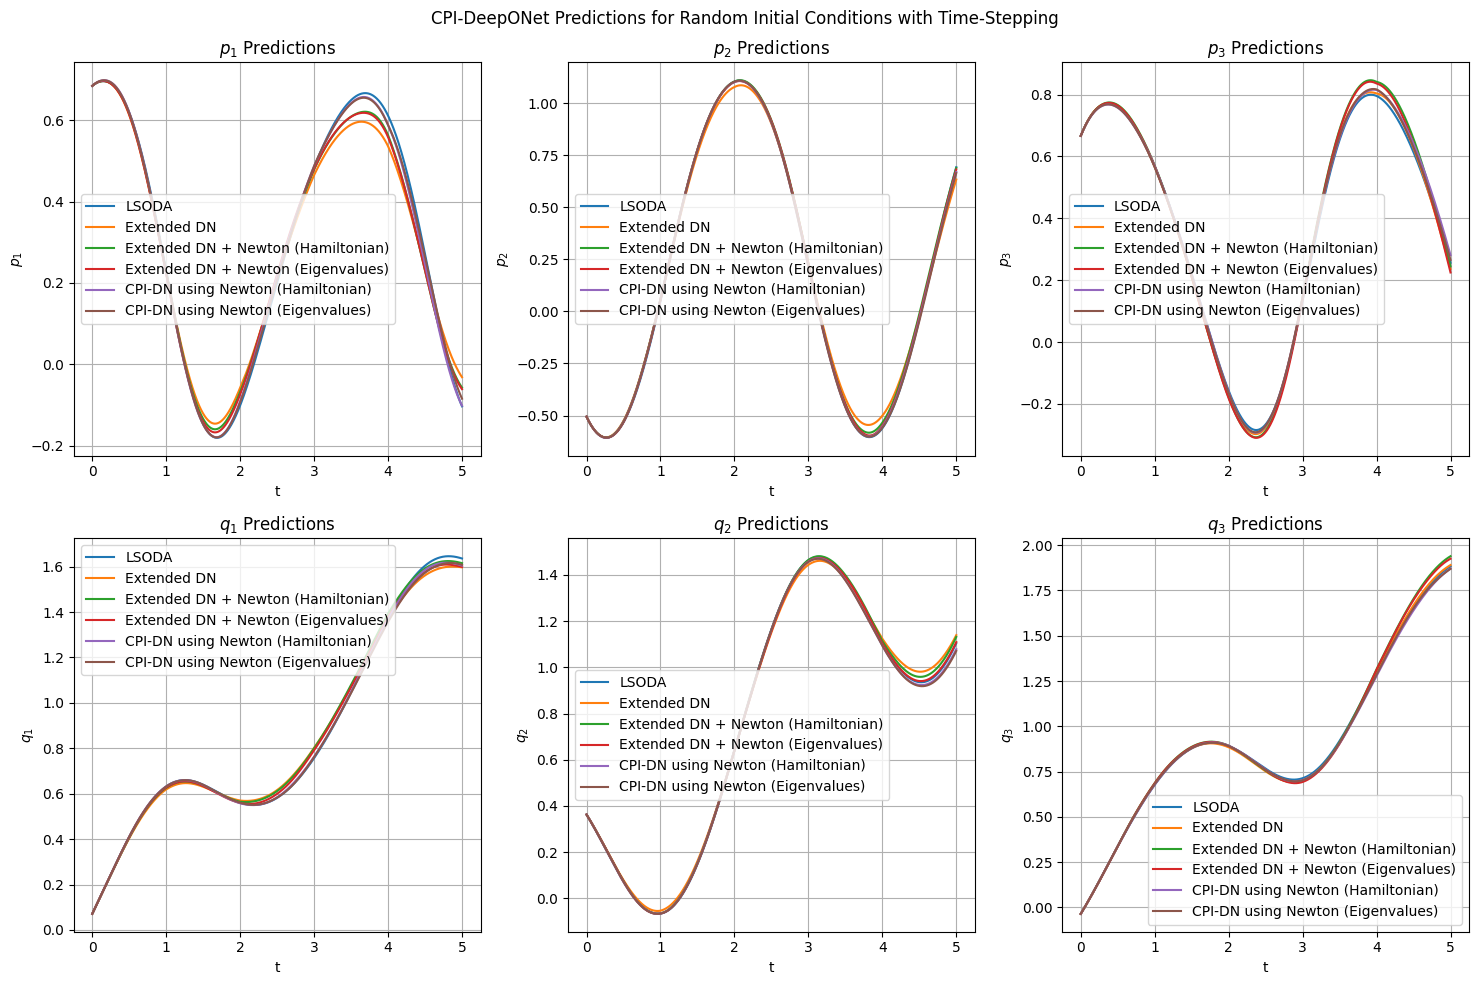

In [156]:
n = 500
t_end = t_end_val

num_cycles = int(t_end/tfinal)
n_tot = n*num_cycles
t_tot = np.linspace(t0, t_end, n_tot)

model_no = -1

p1, p2, p3, q1, q2, q3, H = preds[model_no, 0, :, 0, :].flatten(), preds[model_no, 0, :, 1, :].flatten(), preds[model_no, 0, :, 2, :].flatten(), \
                            preds[model_no, 0, :, 3, :].flatten(), preds[model_no, 0, :, 4, :].flatten(), preds[model_no, 0, :, 5, :].flatten(), \
                            preds[model_no, 0, :, 6, :].flatten()

Hp1, Hp2, Hp3, Hq1, Hq2, Hq3, HH = preds[model_no, 1, :, 0, :].flatten(), preds[model_no, 1, :, 1, :].flatten(), preds[model_no, 1, :, 2, :].flatten(), \
                                   preds[model_no, 1, :, 3, :].flatten(), preds[model_no, 1, :, 4, :].flatten(), preds[model_no, 1, :, 5, :].flatten(), \
                                   preds[model_no, 1, :, 6, :].flatten()

Ep1, Ep2, Ep3, Eq1, Eq2, Eq3, EH = preds[model_no, 2, :, 0, :].flatten(), preds[model_no, 2, :, 1, :].flatten(), preds[model_no, 2, :, 2, :].flatten(), \
                                   preds[model_no, 2, :, 3, :].flatten(), preds[model_no, 2, :, 4, :].flatten(), preds[model_no, 2, :, 5, :].flatten(), \
                                   preds[model_no, 2, :, 6, :].flatten()


HCp1, HCp2, HCp3, HCq1, HCq2, HCq3, HCH = preds[model_no, 3, :, 0, :].flatten(), preds[model_no, 3, :, 1, :].flatten(), preds[model_no, 3, :, 2, :].flatten(), \
                                          preds[model_no, 3, :, 3, :].flatten(), preds[model_no, 3, :, 4, :].flatten(), preds[model_no, 3, :, 5, :].flatten(), \
                                          preds[model_no, 3, :, 6, :].flatten()


ECp1, ECp2, ECp3, ECq1, ECq2, ECq3, ECH = preds[model_no, 4, :, 0, :].flatten(), preds[model_no, 4, :, 1, :].flatten(), preds[model_no, 4, :, 2, :].flatten(), \
                                          preds[model_no, 4, :, 3, :].flatten(), preds[model_no, 4, :, 4, :].flatten(), preds[model_no, 4, :, 5, :].flatten(), \
                                          preds[model_no, 4, :, 6, :].flatten()





fig = plt.figure(figsize=(15, 10))
fig.suptitle("CPI-DeepONet Predictions for Random Initial Conditions with Time-Stepping")

plt.subplot(2, 3, 1)
plt.tight_layout()
plt.plot(t_tot, p1_rk)
plt.plot(t_tot, p1)
plt.plot(t_tot, Hp1)
plt.plot(t_tot, Ep1)
plt.plot(t_tot, HCp1)
plt.plot(t_tot, ECp1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_1$')
plt.title(r'$p_1$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])


plt.subplot(2, 3, 2)
plt.tight_layout()
plt.plot(t_tot, p2_rk)
plt.plot(t_tot, p2)
plt.plot(t_tot, Hp2)
plt.plot(t_tot, Ep2)
plt.plot(t_tot, HCp2)
plt.plot(t_tot, ECp2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_2$')
plt.title(r'$p_2$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 3)
plt.tight_layout()
plt.plot(t_tot, p3_rk)
plt.plot(t_tot, p3)
plt.plot(t_tot, Hp3)
plt.plot(t_tot, Ep3)
plt.plot(t_tot, HCp3)
plt.plot(t_tot, ECp3)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$p_3$')
plt.title(r'$p_3$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 4)
plt.tight_layout()
plt.plot(t_tot, q1_rk)
plt.plot(t_tot, q1)
plt.plot(t_tot, Hq1)
plt.plot(t_tot, Eq1)
plt.plot(t_tot, HCq1)
plt.plot(t_tot, ECq1)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_1$')
plt.title(r'$q_1$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 5)
plt.tight_layout()
plt.plot(t_tot, q2_rk)
plt.plot(t_tot, q2)
plt.plot(t_tot, Hq2)
plt.plot(t_tot, Eq2)
plt.plot(t_tot, HCq2)
plt.plot(t_tot, ECq2)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_2$')
plt.title(r'$q_2$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

plt.subplot(2, 3, 6)
plt.tight_layout()
plt.plot(t_tot, q3_rk)
plt.plot(t_tot, q3)
plt.plot(t_tot, Hq3)
plt.plot(t_tot, Eq3)
plt.plot(t_tot, HCq3)
plt.plot(t_tot, ECq3)
plt.grid()
plt.xlabel('t')
plt.ylabel(r'$q_3$')
plt.title(r'$q_3$' + ' Predictions')
plt.legend(['LSODA', 'Extended DN', 'Extended DN + Newton (Hamiltonian)', \
            'Extended DN + Newton (Eigenvalues)', 'CPI-DN using Newton (Hamiltonian)', 'CPI-DN using Newton (Eigenvalues)'])

#fig.savefig("Toda3_cpi_preds_2500+2500ep.png")